<a href="https://colab.research.google.com/github/jasmidd/MSSP6070/blob/main/WeeklyModules/Week06/Data_Quality_Ethics_Housing_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Quality Assessment and Ethical Use of Data

**Data analytics case study:** housing prices. This notebook uses the uploaded `HousingPrices.csv` file to demonstrate a practical data-quality audit and the ethical questions that should accompany each analysis decision.

By the end, you should be able to build a reproducible quality report, diagnose missingness, validity, consistency, duplicates, outliers, and measurement limitations, and translate technical findings into ethical safeguards for a data analysis workflow.

## 1. Data-analysis workflow with ethics gates

A defensible workflow is not just: load → clean → model → report. At graduate level, every technical step should have an ethics gate:

1. **Frame the question.** Who benefits, who could be harmed, and what decisions might use the output?
2. **Understand provenance.** Where did the data come from, under what consent or license, and for what original purpose?
3. **Assess quality.** Check completeness, validity, consistency, uniqueness, accuracy proxies, timeliness, and fitness for use.
4. **Prepare data.** Make cleaning choices transparent and reversible; document all exclusions and imputations.
5. **Analyze/model.** Avoid overclaiming causality, test robustness, and check subgroup performance when protected or sensitive attributes are available.
6. **Communicate.** Report limitations, uncertainty, and appropriate uses/non-uses.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
import statsmodels.api as se
import seaborn as sns
import datetime as dt
from sklearn.linear_model import LinearRegression
from scipy import stats
from io import StringIO
import itertools

pd.set_eng_float_format(accuracy=3, use_eng_prefix=True)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Penn2001' # Replace with the GitHub repository owner
repository = 'MSSP-607' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directoGit_HUBry to: {os.getcwd()}")


Changed directoGit_HUBry to: /content/MSSP-607/MSSP-607


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# The notebook works when placed either in /mnt/data or in the same folder as the CSV.
DATA_PATH = Path("/content/MSSP-607/data/HousingPrices.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("HousingPrices.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,Id,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,FullBath,TotalRooms,GarageCars,GarageArea,YrSold,SalePrice
0,1,65.000,"8,450.000",2Story,7,5,2003,856.000,Y,856,854,2,8,2,548,2008,208500
1,2,80.000,"9,600.000",1Story,6,8,1976,NaN,Y,1262,0,2,6,2,460,2007,181500
2,3,68.000,"11,250.000",2Story,7,5,2001,920.000,Y,920,866,2,6,2,608,2008,223500
3,4,60.000,"9,550.000",2Story,7,5,1915,NaN,Y,961,756,1,7,3,642,2006,140000
4,5,84.000,"14,260.000",2Story,8,5,2000,"1,145.000",Y,1145,1053,2,9,3,836,2008,250000


In [ ]:
#
print(f"Rows: {df.shape[0]:,}") #print total number of rows.
print(f"Columns: {df.shape[1]:,}") #print total number of columns
df.info()

Rows: 1,460
Columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           1460 non-null   int64  
 1   LotFrontage  1201 non-null   float64
 2   LotArea      1341 non-null   float64
 3   HouseStyle   1460 non-null   object 
 4   OverallQual  1460 non-null   int64  
 5   OverallCond  1460 non-null   int64  
 6   YearBuilt    1460 non-null   int64  
 7   TotalBsmtSF  913 non-null    float64
 8   CentralAir   1460 non-null   object 
 9   1stFlrSF     1460 non-null   int64  
 10  2ndFlrSF     1460 non-null   int64  
 11  FullBath     1460 non-null   int64  
 12  TotalRooms   1460 non-null   int64  
 13  GarageCars   1460 non-null   int64  
 14  GarageArea   1460 non-null   int64  
 15  YrSold       1460 non-null   int64  
 16  SalePrice    1460 non-null   int64  
dtypes: float64(3), int64(12), object(2)
memory usage: 194.0+ KB


## 2. Create a compact data dictionary

A data dictionary is a quality-control instrument. It makes assumptions visible before they become silent model behavior.

In [ ]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(1).values,
    "unique_values": df.nunique(dropna=True).values,
})
data_dictionary

,column,dtype,non_null,missing,missing_pct,unique_values
0,Id,int64,1460,0,0.000,1460
1,LotFrontage,float64,1201,259,17.700,110
2,LotArea,float64,1341,119,8.200,993
3,HouseStyle,object,1460,0,0.000,8
4,OverallQual,int64,1460,0,0.000,10
5,OverallCond,int64,1460,0,0.000,9
6,YearBuilt,int64,1460,0,0.000,112
7,TotalBsmtSF,float64,913,547,37.500,541
8,CentralAir,object,1460,0,0.000,2
9,1stFlrSF,int64,1460,0,0.000,753


## 3. Completeness: missing values

Missing values are not automatically errors. They may mean “not applicable,” “not collected,” “unknown,” or “lost during integration.” The ethical issue is that missingness can be unevenly distributed across groups or contexts, causing downstream bias.

In [ ]:
missing = (df.isna().sum()
           .to_frame("missing_rows")
           .assign(missing_pct=lambda x: (x["missing_rows"] / len(df) * 100).round(1))
           .sort_values("missing_rows", ascending=False))
missing[missing["missing_rows"] > 0]

,missing_rows,missing_pct
TotalBsmtSF,547,37.500
LotFrontage,259,17.700
LotArea,119,8.200


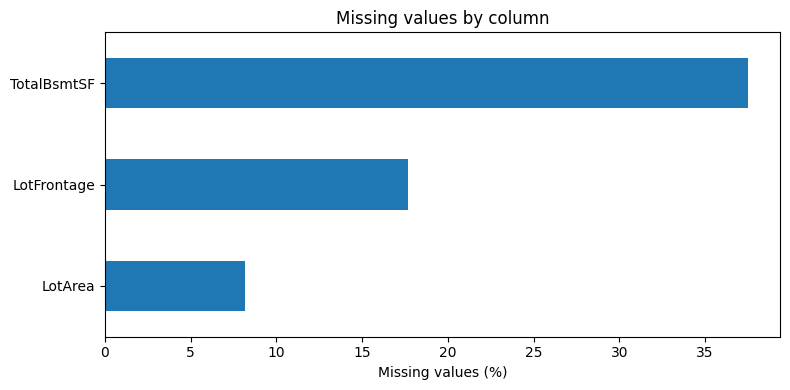

In [ ]:
#Filters your missing summary DataFrame to keep only the columns that actually have
#missing data (where missing_rows is greater than 0).
missing_nonzero = missing[missing["missing_rows"] > 0].sort_values("missing_pct")
ax = missing_nonzero["missing_pct"].plot(kind="barh", figsize=(8, 4), title="Missing values by column")
ax.set_xlabel("Missing values (%)")
plt.tight_layout()
plt.show()

### Decision log: missingness

For this dataset, `LotFrontage`, `LotArea`, and `TotalBsmtSF` have missing values. Before imputation (filling in missing data), ask whether a missing basement size means no basement, a measurement gap, or a merge problem. Those meanings lead to different cleaning choices.

In [ ]:
# Example: simple missingness indicators preserve information about missingness mechanisms.
quality_df = df.copy()
for col in ["LotFrontage", "LotArea", "TotalBsmtSF"]:
    quality_df[f"{col}_was_missing"] = quality_df[col].isna().astype(int)

quality_df[["LotFrontage", "LotFrontage_was_missing", "LotArea", "LotArea_was_missing", "TotalBsmtSF", "TotalBsmtSF_was_missing"]].head(8)

,LotFrontage,LotFrontage_was_missing,LotArea,LotArea_was_missing,TotalBsmtSF,TotalBsmtSF_was_missing
0,65.000,0,"8,450.000",0,856.000,0
1,80.000,0,"9,600.000",0,NaN,1
2,68.000,0,"11,250.000",0,920.000,0
3,60.000,0,"9,550.000",0,NaN,1
4,84.000,0,"14,260.000",0,"1,145.000",0
5,85.000,0,"14,115.000",0,NaN,1
6,75.000,0,"10,084.000",0,"1,686.000",0
7,NaN,1,"10,382.000",0,"1,107.000",0


## 4. Validity and schema checks

Validity checks compare observed values to rules implied by the domain. Rules should be justified, not invented solely to make the data look clean....validation should be based on real-world knowledge, not on arbitrary assumptions.

In [ ]:
validity_checks = {
    "Id_is_unique": df["Id"].is_unique,
    "SalePrice_positive": (df["SalePrice"] > 0).all(),
    "YearBuilt_reasonable": df["YearBuilt"].between(1800, df["YrSold"].max()).all(),
    "YrSold_range_expected": df["YrSold"].between(2006, 2010).all(),
    "OverallQual_1_to_10": df["OverallQual"].between(1, 10).all(),
    "OverallCond_1_to_10": df["OverallCond"].between(1, 10).all(),
    "CentralAir_Y_or_N": df["CentralAir"].isin(["Y", "N"]).all(),
    "No_negative_square_footage": (df[["LotArea", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GarageArea"]].min(skipna=True) >= 0).all(),
}
pd.Series(validity_checks, name="passed")

,passed
Id_is_unique,True
SalePrice_positive,True
YearBuilt_reasonable,True
YrSold_range_expected,True
OverallQual_1_to_10,True
OverallCond_1_to_10,True
CentralAir_Y_or_N,True
No_negative_square_footage,True


In [ ]:
#Records that deserve review because the house appears to be built after it was sold.
#Performs a logical validation check to flag any potential data-entry errors in your dataset:
df.loc[df["YearBuilt"] > df["YrSold"], ["Id", "YearBuilt", "YrSold", "SalePrice"]]

,Id,YearBuilt,YrSold,SalePrice


## 5. Uniqueness and consistency

Duplicates can over-weight certain examples. Consistency checks look for combinations that violate business logic, such as zero garage cars with positive garage area.

In [ ]:
print("Full-row duplicates:", df.duplicated().sum())
print("Duplicate Id values:", df["Id"].duplicated().sum())

consistency_issues = pd.DataFrame({
    "zero_garage_cars_positive_area": ((df["GarageCars"] == 0) & (df["GarageArea"] > 0)),
    "positive_garage_cars_zero_area": ((df["GarageCars"] > 0) & (df["GarageArea"] == 0)),
    "zero_bath_many_rooms": ((df["FullBath"] == 0) & (df["TotalRooms"] >= 6)),
})
consistency_issues.sum().sort_values(ascending=False)

Full-row duplicates: 0
Duplicate Id values: 0


,0
zero_bath_many_rooms,3
zero_garage_cars_positive_area,0
positive_garage_cars_zero_area,0


In [ ]:
issue_rows = df.loc[consistency_issues.any(axis=1), ["Id", "GarageCars", "GarageArea", "FullBath", "TotalRooms", "SalePrice"]]
issue_rows.head(10)

,Id,GarageCars,GarageArea,FullBath,TotalRooms,SalePrice
188,189,2,528,0,6,153337
597,598,3,648,0,7,194201
1163,1164,2,400,0,6,108959


## 6. Distribution checks and outliers

Outliers can be errors, rare but valid cases, or important evidence. Removing them only because they are inconvenient can distort the population and hide precisely the cases where a model will fail.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
summary = df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary[["count", "mean", "std", "min", "1%", "5%", "50%", "95%", "99%", "max"]]

,count,mean,std,min,1%,5%,50%,95%,99%,max
Id,"1,460.000",730.500,421.610,1.000,15.590,73.950,730.500,"1,387.050","1,445.410","1,460.000"
LotFrontage,"1,201.000",70.050,24.285,21.000,21.000,34.000,69.000,107.000,141.000,313.000
LotArea,"1,341.000","10,440.100","10,051.013","1,300.000","1,680.000","3,230.000","9,382.000","17,217.000","34,939.800","215,245.000"
OverallQual,"1,460.000",6.099,1.383,1.000,3.000,4.000,6.000,8.000,10.000,10.000
OverallCond,"1,460.000",5.575,1.113,1.000,3.000,4.000,5.000,8.000,9.000,9.000
YearBuilt,"1,460.000","1,971.268",30.203,"1,872.000","1,899.180","1,916.000","1,973.000","2,007.000","2,009.000","2,010.000"
TotalBsmtSF,913.000,"1,055.814",409.495,0.000,0.000,520.000,996.000,"1,732.800","2,105.280","3,206.000"
1stFlrSF,"1,460.000","1,162.627",386.588,334.000,520.000,672.950,"1,087.000","1,831.250","2,219.460","4,692.000"
2ndFlrSF,"1,460.000",346.992,436.528,0.000,0.000,0.000,0.000,"1,141.050","1,418.920","2,065.000"
FullBath,"1,460.000",1.565,0.551,0.000,1.000,1.000,2.000,2.000,3.000,3.000


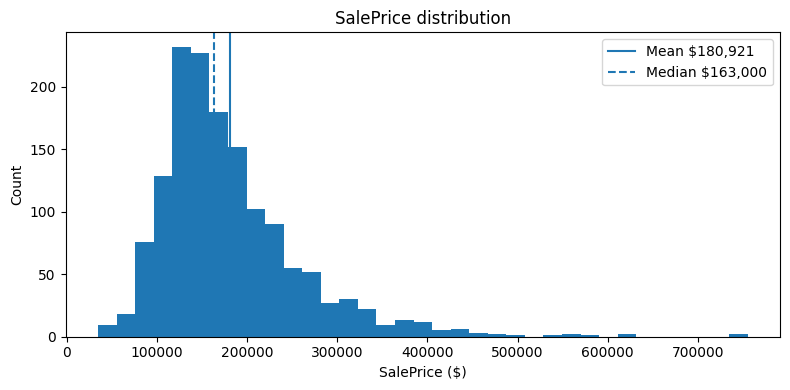

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["SalePrice"], bins=35)
ax.axvline(df["SalePrice"].mean(), linestyle="-", label=f"Mean ${df['SalePrice'].mean():,.0f}")
ax.axvline(df["SalePrice"].median(), linestyle="--", label=f"Median ${df['SalePrice'].median():,.0f}")
ax.set_title("SalePrice distribution")
ax.set_xlabel("SalePrice ($)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def iqr_flags(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

outlier_report = pd.DataFrame({
    "iqr_outliers": {col: int(iqr_flags(df[col].dropna()).sum()) for col in num_cols},
    "outlier_pct": {col: round(iqr_flags(df[col].dropna()).mean() * 100, 1) for col in num_cols},
}).sort_values("iqr_outliers", ascending=False)
outlier_report

,iqr_outliers,outlier_pct
OverallCond,125,8.600
LotFrontage,88,7.300
LotArea,67,5.000
SalePrice,61,4.200
TotalBsmtSF,38,4.200
TotalRooms,30,2.100
GarageArea,21,1.400
1stFlrSF,20,1.400
YearBuilt,7,0.500
GarageCars,5,0.300


In [ ]:
# Inspect the most extreme lots instead of deleting them automatically.
df.nlargest(10, "LotArea")[["Id", "LotArea", "HouseStyle", "OverallQual", "YearBuilt", "SalePrice"]]

,Id,LotArea,HouseStyle,OverallQual,YearBuilt,SalePrice
313,314,"215,245.000",1Story,7,1965,375000
335,336,"164,660.000",1.5Fin,5,1965,228950
249,250,"159,000.000",1.5Fin,6,1958,277000
706,707,"115,149.000",1Story,7,1971,302000
1298,1299,"63,887.000",2Story,10,2008,160000
769,770,"53,504.000",2Story,8,2003,538000
457,458,"53,227.000",1Story,4,1954,256000
53,54,"50,271.000",1Story,9,1981,385000
661,662,"46,589.000",2Story,8,1994,402000
848,849,"45,600.000",1.5Fin,6,1908,240000


## 7. Relationship checks: predictive signal and proxy risk

A feature can be predictive and ethically sensitive at the same time. In housing, variables such as quality ratings, lot size, and square footage can correlate with neighborhood-level wealth, historical segregation, lending access, or appraisal practices even if those variables are not explicitly protected attributes.

In [ ]:
corr_to_price = df.select_dtypes(include=np.number).corr(numeric_only=True)["SalePrice"].drop("SalePrice").sort_values(key=lambda s: s.abs(), ascending=False)
corr_to_price.head(10).to_frame("correlation_with_SalePrice")

,correlation_with_SalePrice
OverallQual,0.791
TotalBsmtSF,0.642
GarageCars,0.640
GarageArea,0.623
1stFlrSF,0.606
FullBath,0.561
TotalRooms,0.534
YearBuilt,0.523
LotFrontage,0.352
2ndFlrSF,0.319


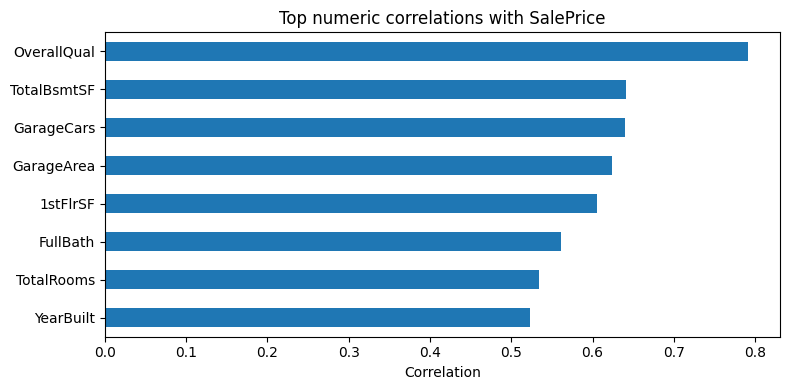

In [ ]:
ax = corr_to_price.head(8).sort_values().plot(kind="barh", figsize=(8, 4), title="Top numeric correlations with SalePrice")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()

## 8. A reusable quality scorecard

The goal is not to reduce quality to a single number. The scorecard below creates a structured checklist that supports reproducible review and discussion.

In [ ]:
scorecard = pd.DataFrame([
    {"dimension": "Completeness", "test": "Missingness documented", "result": f"{(df.isna().sum() > 0).sum()} columns have missing values", "action": "Add indicators and justify imputation"},
    {"dimension": "Validity", "test": "Domain rules", "result": f"{sum(validity_checks.values())}/{len(validity_checks)} checks passed", "action": "Review failed rules with domain context"},
    {"dimension": "Uniqueness", "test": "Duplicate records and keys", "result": f"{df.duplicated().sum()} full-row duplicates; {df['Id'].duplicated().sum()} duplicate IDs", "action": "Confirm Id is a stable key"},
    {"dimension": "Consistency", "test": "Cross-field logic", "result": f"{int(consistency_issues.any(axis=1).sum())} rows flagged", "action": "Investigate before exclusion"},
    {"dimension": "Outliers", "test": "IQR flags", "result": f"{int(outlier_report['iqr_outliers'].sum())} numeric field-level flags", "action": "Review impact, do not auto-delete"},
    {"dimension": "Ethical fitness", "test": "Use-case and stakeholder review", "result": "Requires human judgment", "action": "Document intended uses, non-uses, and limitations"},
])
scorecard

,dimension,test,result,action
0,Completeness,Missingness documented,3 columns have missing values,Add indicators and justify imputation
1,Validity,Domain rules,8/8 checks passed,Review failed rules with domain context
2,Uniqueness,Duplicate records and keys,0 full-row duplicates; 0 duplicate IDs,Confirm Id is a stable key
3,Consistency,Cross-field logic,3 rows flagged,Investigate before exclusion
4,Outliers,IQR flags,466 numeric field-level flags,"Review impact, do not auto-delete"
5,Ethical fitness,Use-case and stakeholder review,Requires human judgment,"Document intended uses, non-uses, and limitations"


## 9. Cleaning choices with auditability

For instructional purposes, this simple pipeline uses median imputation for selected numeric columns and one-hot encoding for categorical variables. In a real analysis, this is a baseline rather than a final answer. Always compare against alternatives and document the consequences.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

features = [c for c in df.columns if c not in ["Id", "SalePrice"]]
X = df[features]
y = df["SalePrice"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", LinearRegression()),
])

rmse_scores = -cross_val_score(model, X, y, cv=5, scoring="neg_root_mean_squared_error")
print(f"5-fold RMSE: ${rmse_scores.mean():,.0f} +/- ${rmse_scores.std():,.0f}")

5-fold RMSE: $37,986 +/- $5,452


## 10. Ethical reflection prompts for the housing-price case

Use these prompts in your case-study write-up:

- **Purpose limitation:** Is the model for exploratory pricing, taxation, lending, insurance, or public policy? Different uses have different risk levels.
- **Consent and provenance:** Were sellers/buyers aware that their transaction data could be reused for modeling?
- **Proxy discrimination:** Which variables could proxy for socioeconomic status, race, disability, family status, or neighborhood characteristics?
- **Human impact:** What happens if the estimate is wrong for a low-income owner, a renter, or a buyer with limited bargaining power?
- **Contestability:** Can affected people correct inaccurate data or challenge an automated estimate?
- **Transparency:** What caveats must appear beside the model output?
- **Data minimization:** Which fields are necessary for the stated purpose, and which should be excluded?

## 11. Recommended deliverable format

A rigorous case-study submission should include:

1. A data dictionary and provenance statement.
2. A quality scorecard with evidence for each dimension.
3. A cleaning decision log listing every imputation, exclusion, recoding, and outlier treatment.
4. A baseline analysis or model with uncertainty and robustness checks.
5. An ethics section describing intended use, affected stakeholders, risks, mitigations, and non-uses.

## 12. Closing principle

Data quality and ethics are inseparable: poor quality can create ethical harm, and ethical blind spots can make technically “clean” data unfit for use.